# 指数関数と対数関数

## 指数関数

:::{admonition} （定義）指数関数

$a$をある定数として、

$$
y = a^x
$$

を、$a$を **底** とする **指数関数**（exponential function）という。
:::

### ネイピア数

以下で定義される定数$e$をネイピア数という

$$
\lim _{n \rightarrow \infty}\left(1+\frac{1}{n}\right)^n=e=2.7182818 \cdots
$$



:::{admonition} （定義）自然指数関数

$e$を底とする指数関数

$$
y = e^x
$$

を **指数関数**（the exponential function）あるいは明示的に **自然指数関数**という。
:::

（英語だとtheがつくかどうかで底の違いを表現する。日本語だとややこしいが、標準的な指数関数は$e$を底とする指数関数である）

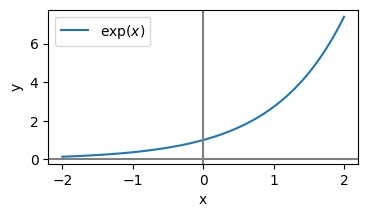

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 100)
y = np.array([np.exp(xi) for xi in x])

fig, ax = plt.subplots(figsize=[4, 2])
ax.plot(x, y, label=r"$\exp(x)$")
ax.set(xlabel="x", ylabel="y")
ax.axhline(color="gray")
ax.axvline(color="gray")
ax.legend()
fig.show()

$x=0$のとき、$e^0 = 1$

$x=1$のとき、$e^1 = e$

$x=-1$のとき、$e^{-1} = \frac{1}{e} = 0.3678 \cdots$

:::{admonition} （定義）自然指数関数

指数関数にはいくつかの定義があり、オイラーによって最初に定義されたものは以下のものになる

$$
\exp (x)=\lim _{n \rightarrow \infty}\left(1+\frac{x}{n}\right)^n
$$

マクローリン級数によって冪級数の形にした

$$
\exp (x)=\sum_{n=0}^{\infty} \frac{x^n}{n !}=1+x+\frac{x^2}{2 !}+\frac{x^3}{3 !}+\frac{x^4}{4 !}+\cdots
$$

の定義もある
:::


$\left(1+\frac{x}{n}\right)^n$を有限の範囲でいくつか試すと以下のようになる

In [2]:
x = 1
for n in range(1, 6):
    e = (1 + (x / n))**n
    print(f"{n=}, {e=:.3f}")

n=1, e=2.000
n=2, e=2.250
n=3, e=2.370
n=4, e=2.441
n=5, e=2.488


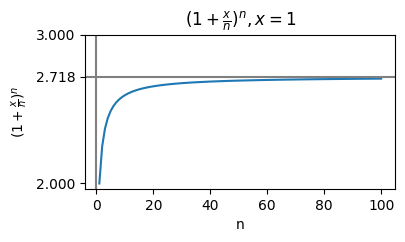

In [9]:
import numpy as np
import matplotlib.pyplot as plt

N = np.linspace(1, 100, 101)
E = [(1 + (x / n))**n for n in N]

fig, ax = plt.subplots(figsize=[4, 2])
ax.plot(N, E)
ax.set(
    xlabel="n",
    ylabel=r"$(1 + \frac{x}{n})^n$",
    title=r"$(1 + \frac{x}{n})^n, x=1$",
    yticks=[2, np.exp(1),3],
)
ax.axhline(np.exp(1), color="gray")
ax.axvline(color="gray")
fig.show()

### 指数(関数)の基本的性質（指数法則）

:::{admonition} 指数法則

$$
\begin{align}
a^x a^y &= a^{x+y}
\\
\left(a^x\right)^y &= a^{x y}
\\
\frac{a^x}{a^y} &= a^{x-y}
\\
\left(\frac{a}{b}\right)^x &= \frac{a^x}{b^x}
\end{align}
$$
:::

:::{card} 例：$x^{-1}$ は？

$x^{-1}$と$x$を乗じれば$x^{-1} \times x^1 = x^{-1 + 1} = x^0 = 1$となる。

なので$x^{-1} = \frac{1}{x}$となる。一般に$x^{-n}$も同様。

:::

:::{card} 例：$x^{\frac{1}{2}}$ は？

$x^{\frac{1}{2}}$と$x^{\frac{1}{2}}$を乗じれば$x^{\frac{1}{2}} \times x^{\frac{1}{2}} = x^{\frac{1}{2} + \frac{1}{2}} = x$となる。

なので$x^{\frac{1}{2}} = \sqrt{x}$

:::

#### $x$を0.01増やすと$y$が1%増える

:::{admonition} $x$を0.01増やすと$y$が1%増える
:class: tip

自然指数関数

$$
y = \exp(x) = e^x
$$

は、$x$を0.01増やすと$y$が1%増えるように底が調整されている（底がネイピア数$e$だとそのようになる）

:::


この誤差は$x$が大きくなるにつれて大きくなる


In [4]:
import numpy as np
import pandas as pd

x = np.linspace(0, 0.1, 11)
y = np.exp(x)

display(pd.DataFrame(dict(x=x, y=y)).round(3))

,x,y
0,0.00,1.000
1,0.01,1.010
2,0.02,1.020
3,0.03,1.030
4,0.04,1.041
5,0.05,1.051
6,0.06,1.062
7,0.07,1.073
8,0.08,1.083
9,0.09,1.094


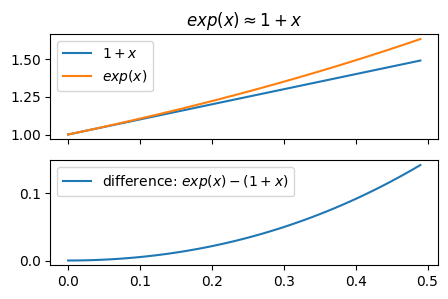

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 0.5, 0.01)
y = np.exp(x)

fig, axes = plt.subplots(figsize=[5, 3], nrows=2, sharex=True)
axes[0].plot(x, 1+x, label=r"$1 + x$")
axes[0].plot(x, y, label=r"$exp(x)$")
axes[0].legend()
axes[1].plot(x, y - (1+x), label=r"difference: $exp(x) - (1 + x)$")
axes[1].legend()
axes[0].set(title=r"$exp(x) \approx 1 + x$")
plt.show()

## 対数関数

指数関数の逆関数を **対数関数** （logarithmic function）という。

$a^y = x$のとき、「$y$は$a$を **底** とする $x$ の対数」といい

$$
y = \log_{a} x
$$

と表す。

:::{admonition} （定義）対数
$a > 0, a \neq 1, M > 0$について

$$
a^m = M
\Longleftrightarrow
m = \log_a M
$$
:::

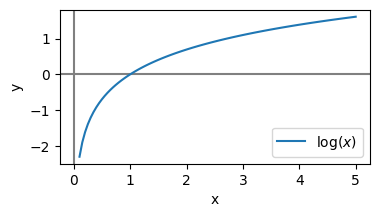

In [28]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.1, 5, 100)
y = np.array([np.log(xi) for xi in x])

fig, ax = plt.subplots(figsize=[4, 2])
ax.axhline(color="gray")
ax.axvline(color="gray")
ax.plot(x, y, label=r"$\log(x)$")
ax.set(xlabel="x", ylabel="y")
ax.legend()
fig.show()

### 自然対数

底（base）がネイピア数 $e$ の対数を自然対数という。

$$
\ln x := \log_e x
$$

また自然対数は指数関数$e^x$の逆関数として定義される（「$e$を何乗したら$x$になるか？」が$\ln x$）

$$
y=\ln x \quad \Longleftrightarrow \quad e^y=x
$$



### 対数関数の性質

$a > 0, a \neq 1, b > 0, M > 0, N > 0$に対して

$$
\begin{align}
\log_a 1 &= 0\\
\log_a a &= 1\\
\log_a \frac{x}{y} &= \log_a x - \log_a y\\
\log_a xy &= \log_a x + \log_a y\\
\log_a x^y &= y \log_a x\\
\log_b x &= \frac{\log_a x}{\log_a b}\\
\end{align}
$$

:::{card} 例：$a^x$

底が$a$の対数を取る場合

$$
\log_a (a^x) = x
$$


自然対数を使う場合

$$
\ln (a^x) =
x \ln(a) \quad (\because \log x^y = y \log x の性質より)
$$

:::

#### 元本が2倍になる年数は

:::{card}
**例：元本が2倍になる年数は？**

年率5%の利益が複利で運用できるとして、元本が2倍になるには何年かかる？

利率$r$で$n$年間複利運用したときの利益率$\pi$は

$$
(1 + r)^n = \pi
$$

$r=0.05$とすると、$\pi=2$になるのは

$$
(1.05)^n = 2
$$

両辺の対数をとると

$$
\log_{10} (1.05)^n = \log_{10} 2
\\
\to n \log_{10} 1.05 = \log_{10} 2
\\
\to n = \frac{ \log_{10} 2 }{ \log_{10} 1.05 } \approx 14.2
$$

なので約14年かかることになる。
:::

In [16]:
import numpy as np
np.log10(2) / np.log10(1.05)

14.206699082890461

#### $\ln(1.01) \approx 0.01$

:::{admonition} $x$を1%増やすと$y = \ln(x)$は0.01増える： $\ln( 1 + 0.01) \approx 0.01$

$\ln(1.01) \approx 0.01$はテイラー近似から導出される。まずテイラー近似について述べる

$f(x)=\ln(x+1)$とおくと、その$n$次の微分は

$$
f^{(n)}(x) = (-1)^{n-1} \frac{(n-1)!}{(x+1)^n}
$$

となる。もし$x=0$なら

$$
f^{(n)}(0) = (-1)^{n-1} \frac{(n-1)!}{(1)^n} = (-1)^{n-1} (n-1)!
$$

となる。

これを$x=0$でのテイラー展開（つまりマクローリン展開）

$$
\sum^{\infty}_{n=0} \frac{f^{(n)}(0)}{n!}x^n = f(0) + f'(0) x + \frac{f^{(2)}(0)}{2!}x^2 + \cdots
$$

にあてはめると、

$$
\ln(1 + x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \cdots
$$

となる。これは$x$が極めて小さな値（$x \approx 0$）であれば$x^2$や$x^3$といった値は非常に小さくなるため、$\ln(1+x) \approx x$となる。

よって$\ln( 1 + 0.01) \approx 0.01$となる


数値計算的に確かめると、以下のようになる

```{code-cell} ipython3
import numpy as np
x = 0.01
print(f"log: {np.log(1 + x):.7f}")
print(f"approx 1: {x:.7f}")
print(f"approx 2: {x - (x**2 / 2):.7f}")
print(f"approx 3: {x - (x**2 / 2) + (x**3 / 3):.7f}")
```

```
log: 0.0099503
approx 1: 0.0100000
approx 2: 0.0099500
approx 3: 0.0099503
```

:::